In [1]:
import pandas as pd

ratings = pd.read_csv('/content/ratings.csv')

movies = pd.read_csv('/content/movies.csv')

print("Ratings DataFrame Head:")
print(ratings.head())
print("\nRatings DataFrame Info:")
ratings.info()

print("\nMovies DataFrame Head:")
print(movies.head())
print("\nMovies DataFrame Info:")
movies.info()

Ratings DataFrame Head:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Ratings DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

Movies DataFrame Head:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (19

In [2]:
user_item_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)

print("User-Item Matrix Head:")
print(user_item_matrix.head())

User-Item Matrix Head:
movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     0.0     4.0     0.0     0.0     4.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           4.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  9       10      ...  193565  193567  193571  193573  193579  193581  \
userId                   ...                                                   
1           0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0  ...     0.0     0.0     0.

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')

kmeans.fit(user_item_matrix)

user_item_matrix['cluster'] = kmeans.labels_

print("First 5 users with their assigned cluster:")
print(user_item_matrix[['cluster']].head())

First 5 users with their assigned cluster:
movieId  cluster
userId          
1              2
2              3
3              3
4              3
5              0


In [4]:
user_clusters = user_item_matrix[['cluster']].reset_index()

ratings_with_clusters = pd.merge(ratings, user_clusters, on='userId', how='left')

print("Ratings DataFrame with Cluster Labels Head:")
print(ratings_with_clusters.head())

Ratings DataFrame with Cluster Labels Head:
   userId  movieId  rating  timestamp  cluster
0       1        1     4.0  964982703        2
1       1        3     4.0  964981247        2
2       1        6     4.0  964982224        2
3       1       47     5.0  964983815        2
4       1       50     5.0  964982931        2


In [5]:
X = ratings_with_clusters[['userId', 'movieId', 'cluster']]
y = ratings_with_clusters['rating']

print("Features (X) Head:")
print(X.head())
print("\nTarget (y) Head:")
print(y.head())

Features (X) Head:
   userId  movieId  cluster
0       1        1        2
1       1        3        2
2       1        6        2
3       1       47        2
4       1       50        2

Target (y) Head:
0    4.0
1    4.0
2    4.0
3    5.0
4    5.0
Name: rating, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (80668, 3)
Shape of X_test: (20168, 3)
Shape of y_train: (80668,)
Shape of y_test: (20168,)


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

gr_model = GradientBoostingRegressor(random_state=42, n_estimators=100)
print("Training GradientBoostingRegressor...")
gr_model.fit(X_train, y_train)
print("GradientBoostingRegressor trained.")

mlp_model = MLPRegressor(random_state=42, max_iter=500, hidden_layer_sizes=(100, 50))
print("Training MLPRegressor...")
mlp_model.fit(X_train, y_train)
print("MLPRegressor trained.")

In [8]:
gr_predictions = gr_model.predict(X_test)
mlp_predictions = mlp_model.predict(X_test)

print("GradientBoostingRegressor Predictions (first 5):")
print(gr_predictions[:5])
print("\nMLPRegressor Predictions (first 5):")
print(mlp_predictions[:5])

GradientBoostingRegressor Predictions (first 5):
[3.61570408 3.32233883 2.65656361 3.60975183 3.62571535]

MLPRegressor Predictions (first 5):
[13.77088285  3.55544037  4.38279453  3.03727284  3.1846943 ]


In [9]:
from sklearn.metrics import mean_squared_error, precision_score, recall_score
import numpy as np

gr_rmse = np.sqrt(mean_squared_error(y_test, gr_predictions))

mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_predictions))

RELEVANCE_THRESHOLD = 4

y_test_binary = (y_test >= RELEVANCE_THRESHOLD).astype(int)
gr_predictions_binary = (gr_predictions >= RELEVANCE_THRESHOLD).astype(int)
mlp_predictions_binary = (mlp_predictions >= RELEVANCE_THRESHOLD).astype(int)

gr_precision = precision_score(y_test_binary, gr_predictions_binary, zero_division=0)
gr_recall = recall_score(y_test_binary, gr_predictions_binary, zero_division=0)

mlp_precision = precision_score(y_test_binary, mlp_predictions_binary, zero_division=0)
mlp_recall = recall_score(y_test_binary, mlp_predictions_binary, zero_division=0)

print(f"\nGradientBoostingRegressor RMSE: {gr_rmse:.4f}")
print(f"GradientBoostingRegressor Precision (threshold={RELEVANCE_THRESHOLD}): {gr_precision:.4f}")
print(f"GradientBoostingRegressor Recall (threshold={RELEVANCE_THRESHOLD}): {gr_recall:.4f}")

print(f"\nMLPRegressor RMSE: {mlp_rmse:.4f}")
print(f"MLPRegressor Precision (threshold={RELEVANCE_THRESHOLD}): {mlp_precision:.4f}")
print(f"MLPRegressor Recall (threshold={RELEVANCE_THRESHOLD}): {mlp_recall:.4f}")


GradientBoostingRegressor RMSE: 0.9835
GradientBoostingRegressor Precision (threshold=4): 0.8177
GradientBoostingRegressor Recall (threshold=4): 0.0458

MLPRegressor RMSE: 5.3361
MLPRegressor Precision (threshold=4): 0.4733
MLPRegressor Recall (threshold=4): 0.3381


In [10]:
model_comparison = {
    'Model': ['GradientBoostingRegressor', 'MLPRegressor'],
    'RMSE': [gr_rmse, mlp_rmse],
    'Precision': [gr_precision, mlp_precision],
    'Recall': [gr_recall, mlp_recall]
}

comparison_df = pd.DataFrame(model_comparison)

print("Model Performance Comparison:")
print(comparison_df)

Model Performance Comparison:
                       Model      RMSE  Precision    Recall
0  GradientBoostingRegressor  0.983467   0.817680  0.045816
1               MLPRegressor  5.336125   0.473281  0.338149


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries matplotlib.pyplot and seaborn imported.")

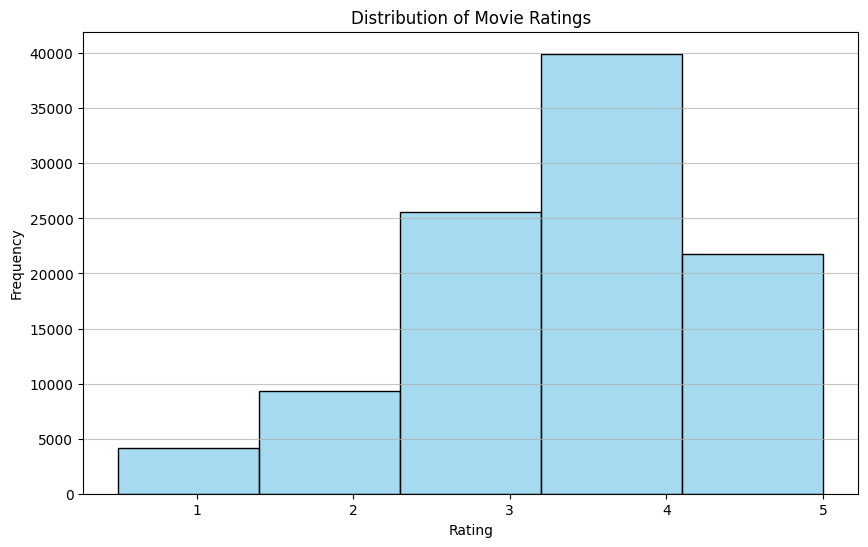

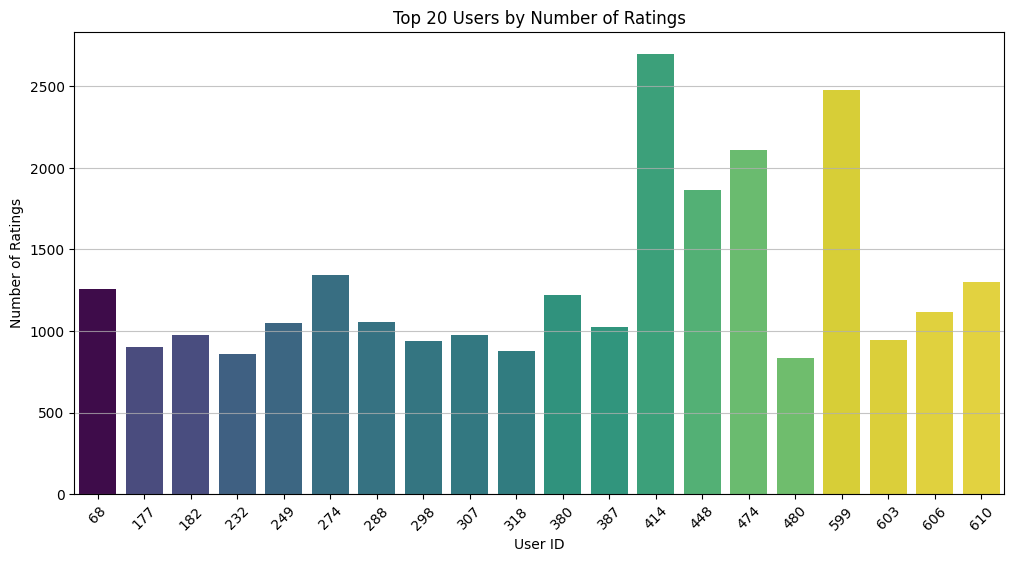

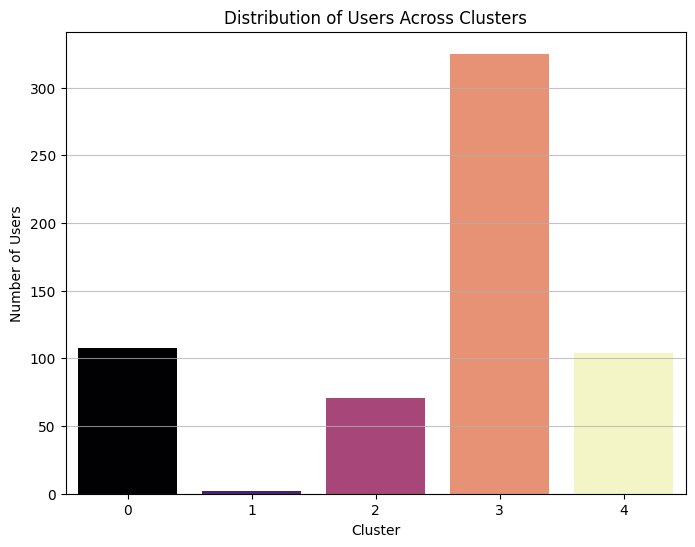

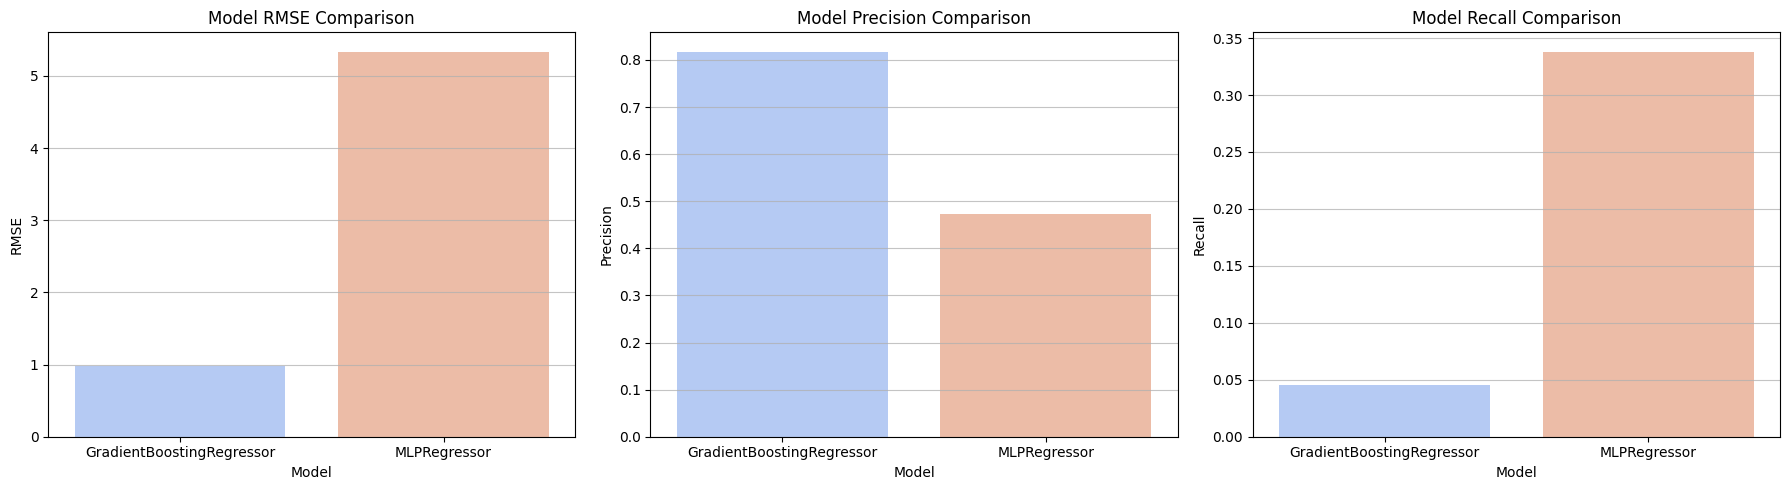

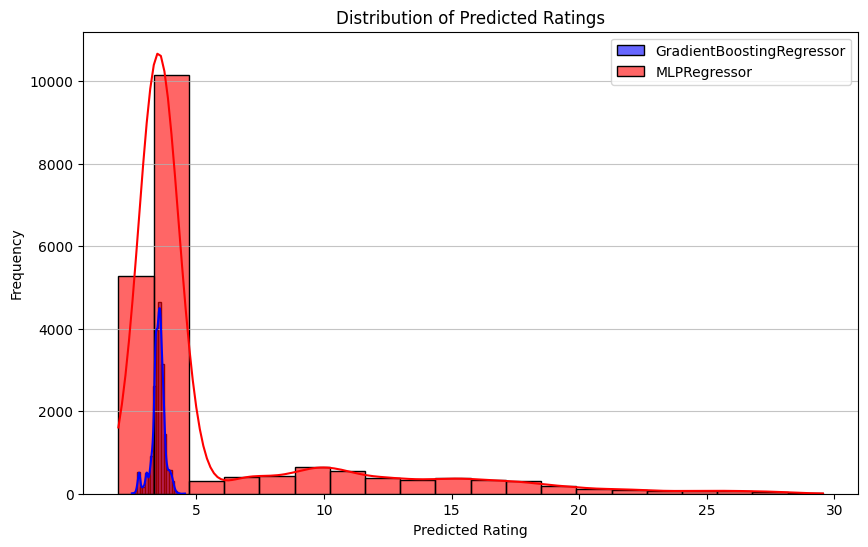

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(ratings['rating'], bins=5, kde=False, color='skyblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


ratings_per_user = ratings.groupby('userId')['rating'].count().sort_values(ascending=False)
top_20_users = ratings_per_user.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_20_users.index, y=top_20_users.values, hue=top_20_users.index, palette='viridis', legend=False)
plt.title('Top 20 Users by Number of Ratings')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.show()


plt.figure(figsize=(8, 6))
sns.countplot(x=user_item_matrix['cluster'], hue=user_item_matrix['cluster'], palette='magma', legend=False)
plt.title('Distribution of Users Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.75)
plt.show()



metrics = ['RMSE', 'Precision', 'Recall']
titles = ['Model RMSE Comparison', 'Model Precision Comparison', 'Model Recall Comparison']
ylabels = ['RMSE', 'Precision', 'Recall']

plt.figure(figsize=(18, 5))
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i + 1)
    sns.barplot(x='Model', y=metric, data=comparison_df, hue='Model', palette='coolwarm', legend=False)
    plt.title(titles[i])
    plt.xlabel('Model')
    plt.ylabel(ylabels[i])
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.histplot(gr_predictions, bins=20, kde=True, color='blue', label='GradientBoostingRegressor', alpha=0.6)
sns.histplot(mlp_predictions, bins=20, kde=True, color='red', label='MLPRegressor', alpha=0.6)
plt.title('Distribution of Predicted Ratings')
plt.xlabel('Predicted Rating')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
def recommend_movies(user_id, model, top_n=5):
    user_cluster = user_item_matrix.loc[user_id, 'cluster']

    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].unique()

    all_movie_ids = movies['movieId'].unique()

    unrated_movie_ids = [movie_id for movie_id in all_movie_ids if movie_id not in rated_movies]

    unrated_movies_df = pd.DataFrame({
        'userId': user_id,
        'movieId': unrated_movie_ids,
        'cluster': user_cluster
    })

    predicted_ratings = model.predict(unrated_movies_df)

    predictions_df = pd.DataFrame({
        'movieId': unrated_movie_ids,
        'predicted_rating': predicted_ratings
    })

    top_recommendations = predictions_df.sort_values(by='predicted_rating', ascending=False).head(top_n)

    recommended_movies_details = pd.merge(top_recommendations, movies, on='movieId', how='left')

    return recommended_movies_details

print("The 'recommend_movies' function has been defined.")

In [15]:
example_user_id = 1
top_n_recommendations = 5

print(f"Recommendations for User ID {example_user_id} using GradientBoostingRegressor:")
gr_recommendations = recommend_movies(example_user_id, gr_model, top_n_recommendations)
print(gr_recommendations[['title', 'genres', 'predicted_rating']])

print(f"\nRecommendations for User ID {example_user_id} using MLPRegressor:")
mlp_recommendations = recommend_movies(example_user_id, mlp_model, top_n_recommendations)
print(mlp_recommendations[['title', 'genres', 'predicted_rating']])

Recommendations for User ID 1 using GradientBoostingRegressor:
                              title                                  genres  \
0                     Dogman (2018)                             Crime|Drama   
1       Ant-Man and the Wasp (2018)  Action|Adventure|Comedy|Fantasy|Sci-Fi   
2        Sorry to Bother You (2018)                   Comedy|Fantasy|Sci-Fi   
3  Won't You Be My Neighbor? (2018)                             Documentary   
4    Solo: A Star Wars Story (2018)        Action|Adventure|Children|Sci-Fi   

   predicted_rating  
0          4.658693  
1          4.658693  
2          4.658693  
3          4.658693  
4          4.658693  

Recommendations for User ID 1 using MLPRegressor:
                                       title                           genres  \
0        Andrew Dice Clay: Dice Rules (1991)                           Comedy   
1        Bungo Stray Dogs: Dead Apple (2018)                 Action|Animation   
2                               Flin